In [1]:
import scanpy as sc
import torch
import numpy as np
import umap
import matplotlib.pyplot as plt


d:\GP\Scimilarity_test\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Baron_Pancreas_Combined_Human_Mouse.h5ad")
print(adata_1)


AnnData object with n_obs × n_vars = 9436 × 10335
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'


In [3]:
adata_1.var.head()

""
A1CF
A4GALT
AAAS
AACS
AADAC


In [4]:
from scimilarity.cell_embedding import CellEmbedding
model_path = r"D:\GP\Scimilarity_test\model\annotation_model_v1"
ce = CellEmbedding(model_path)


In [5]:
adata_1.layers["counts"] = adata_1.X.copy()


In [6]:
from scimilarity.utils import align_dataset, lognorm_counts
adata_1 = align_dataset(adata_1, ce.gene_order)
adata_1 = lognorm_counts(adata_1)

In [7]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from harmonypy import compute_lisi

def compute_silhouette_and_lisi_avg(adata, label_keys, embed_key, k_lisi=30):
  
    X = adata.obsm[embed_key]
    metadata = adata.obs[label_keys]

    # Silhouette scores
    sil_scores = {}
    for key in label_keys:
        labels = adata.obs[key].astype(str).values
        
        if len(np.unique(labels)) > 1:
            sil_scores[key] = silhouette_score(X, labels)
        else:
            sil_scores[key] = np.nan

    # LISI scores
    lisi_scores = compute_lisi(
        X,
        metadata,
        label_colnames=label_keys,
        perplexity=k_lisi
    )

    lisi_df = pd.DataFrame(
        lisi_scores,
        columns=label_keys,
        index=adata.obs_names
    )

    scores = {
        "silhouette": sil_scores,
        "lisi": lisi_df.mean().to_dict()
    }

    return scores

In [8]:

X = adata_1.X
embeddings= ce.get_embeddings(X)
adata_1.obsm["X_emb"] = embeddings

In [9]:
print(embeddings.shape)
# save combined embeddings to project directory
adata_1.write_h5ad(r"D:\GP\Notebooks\Scimilarity\Pancreas_combined_Mouse+Human_embeddings.h5ad")


(9436, 128)


In [10]:
import scanpy as sc

In [11]:
adata_1 = sc.read_h5ad(r"D:\GP\Notebooks\Scimilarity\Pancreas_combined_Mouse+Human_embeddings.h5ad")
print(adata_1)

AnnData object with n_obs × n_vars = 9436 × 28231
    obs: 'barcode', 'cell_type', 'donor_batch', 'source', 'species', 'batch'
    uns: 'orig_genes'
    obsm: 'X_emb'
    layers: 'counts'


In [13]:
label_keys = ["cell_type", "batch", "species"]
# Compute scores
scores = compute_silhouette_and_lisi_avg(adata_1, label_keys, embed_key="X_emb", k_lisi=30)
print("Silhouette Scores:", scores["silhouette"])
print("LISI Scores:", scores["lisi"])


Silhouette Scores: {'cell_type': 0.16818879544734955, 'batch': -0.048268187791109085, 'species': 0.0705798864364624}
LISI Scores: {'cell_type': 1.1452514626759596, 'batch': 1.1355238017887552, 'species': 1.0680424330129348}


In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier

In [15]:
import matplotlib.pyplot as plt

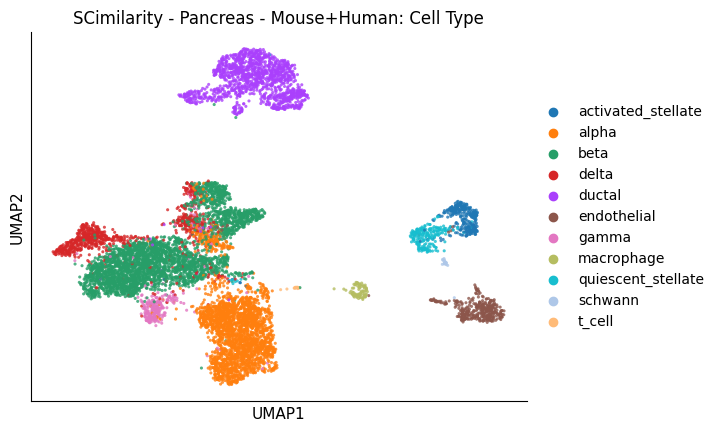

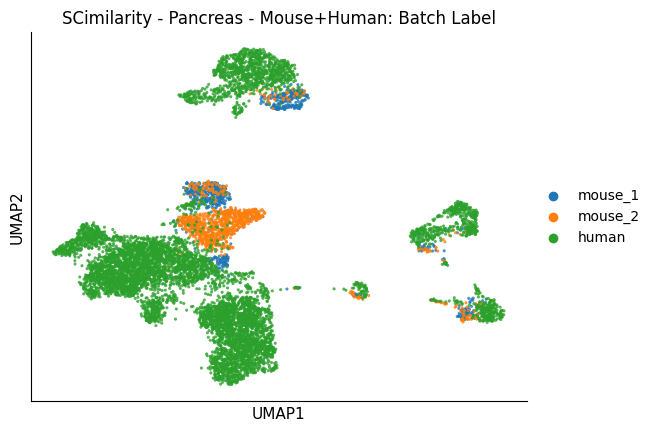

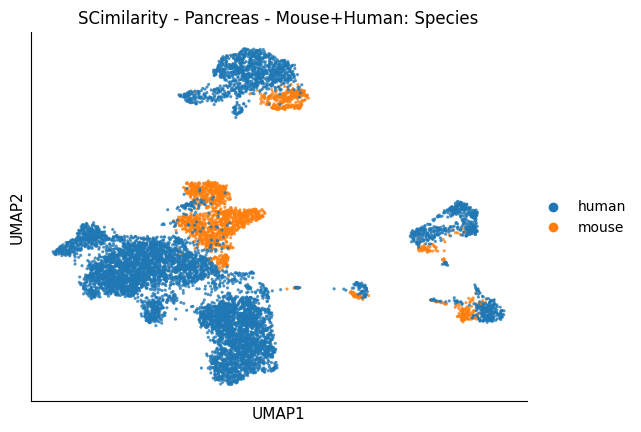

=== Logistic Regression ===
Accuracy: 0.8029978586723768
                    precision    recall  f1-score   support

activated_stellate       0.93      0.93      0.93        14
             alpha       0.51      0.64      0.57       191
              beta       0.79      0.90      0.84       894
             delta       0.88      0.31      0.46       218
            ductal       1.00      0.99      0.99       275
       endothelial       0.99      0.98      0.98       139
             gamma       0.22      0.12      0.16        41
        macrophage       0.92      1.00      0.96        36
quiescent_stellate       0.90      0.94      0.92        47
           schwann       0.00      0.00      0.00         6
            t_cell       1.00      0.57      0.73         7

          accuracy                           0.80      1868
         macro avg       0.74      0.67      0.68      1868
      weighted avg       0.81      0.80      0.79      1868



d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


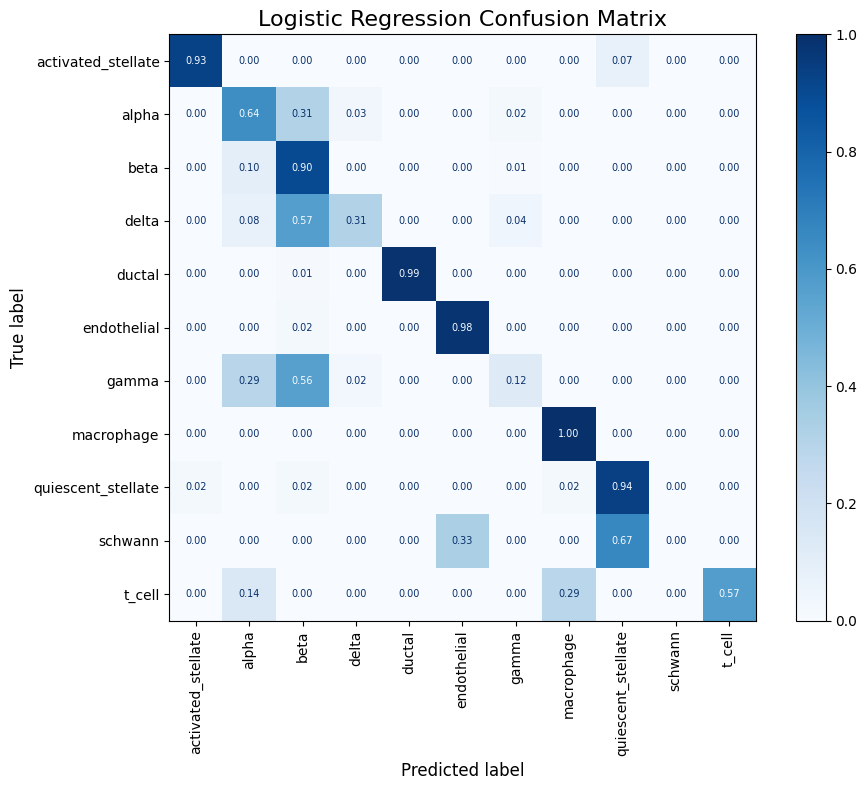


=== k-NN ===
Accuracy: 0.7896145610278372
                    precision    recall  f1-score   support

activated_stellate       0.92      0.86      0.89        14
             alpha       0.57      0.58      0.57       191
              beta       0.80      0.89      0.84       894
             delta       0.84      0.17      0.28       218
            ductal       1.00      0.99      0.99       275
       endothelial       0.99      0.98      0.99       139
             gamma       0.20      0.59      0.29        41
        macrophage       0.97      1.00      0.99        36
quiescent_stellate       0.96      0.94      0.95        47
           schwann       0.83      0.83      0.83         6
            t_cell       1.00      1.00      1.00         7

          accuracy                           0.79      1868
         macro avg       0.83      0.80      0.78      1868
      weighted avg       0.82      0.79      0.78      1868



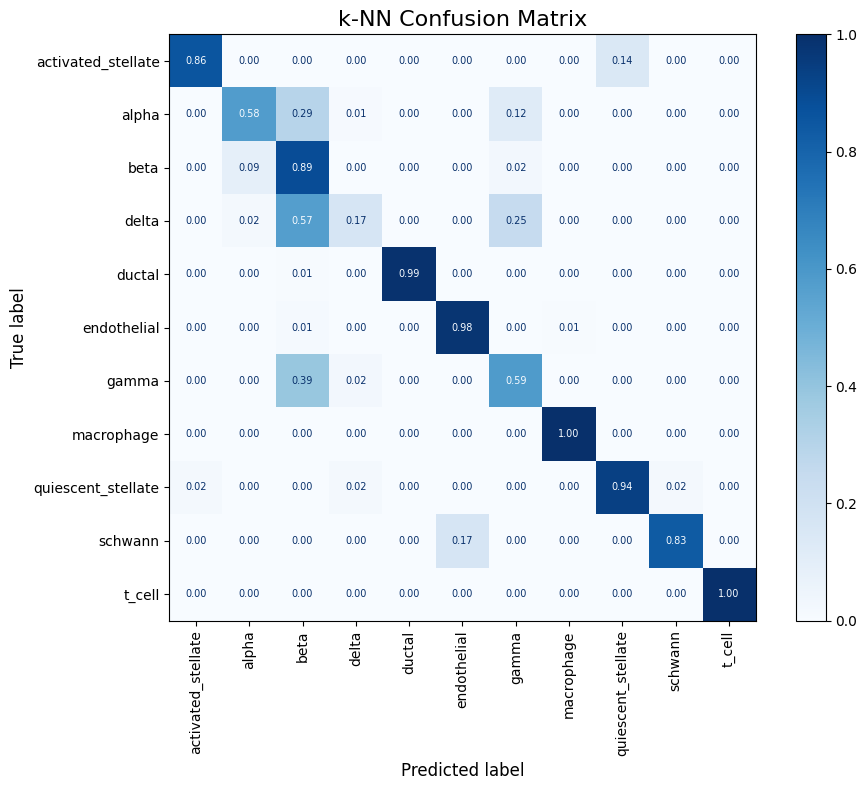

C:\Users\loq\AppData\Local\Temp\ipykernel_23644\2772729903.py:152: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data.obs["y_pred_lr"] = y_pred_lr


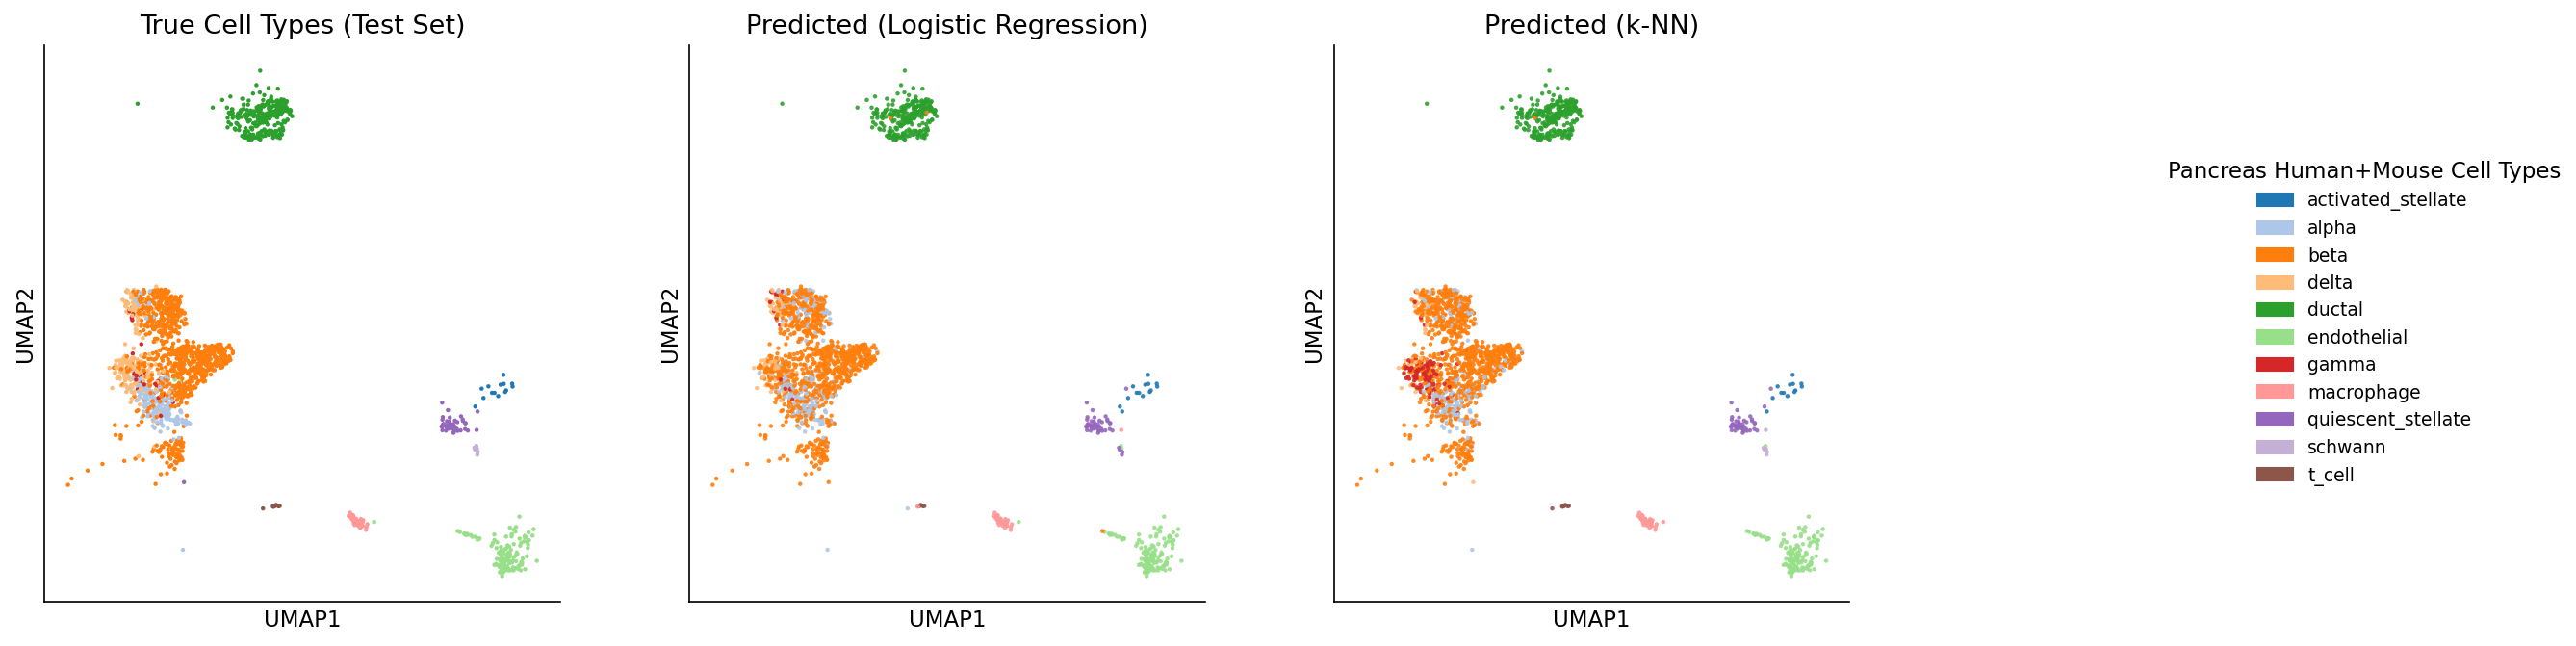

In [ ]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay


sc.pp.neighbors(adata_1, use_rep="X_emb")
sc.tl.umap(adata_1)

ax = sc.pl.umap(
    adata_1,
    color='cell_type',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Pancreas - Mouse+Human: Cell Type"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata_1,
    color='batch',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Pancreas - Mouse+Human: Batch Label"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

ax = sc.pl.umap(
    adata_1,
    color='species',
    size=20,
    alpha=0.8,
    frameon=True,
    show=False,
    title="SCimilarity - Pancreas - Mouse+Human: Species"
)

ax.set_facecolor("white")
ax.set_xlabel("UMAP1", fontsize=11)
ax.set_ylabel("UMAP2", fontsize=11)

# Make axis lines visible
ax.spines[['left', 'bottom']].set_visible(True)

# Remove top/right box lines (clean style)
ax.spines[['top', 'right']].set_visible(False)

# Make axes black
ax.spines[['left', 'bottom']].set_color("black")

plt.show()

## Build a cell-type classifier 

train_data = adata_1[adata_1.obs["species"] != "mouse"]
test_data  = adata_1[adata_1.obs["species"] == "mouse"]

X_train = train_data.obsm["X_emb"]
X_test  = test_data.obsm["X_emb"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Human+Mouse Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()

# Mouse to Human

=== Logistic Regression ===
Accuracy: 0.7094344608879493
                    precision    recall  f1-score   support

activated_stellate       0.98      0.92      0.95       284
             alpha       0.86      0.34      0.49      2326
              beta       0.57      0.97      0.72      2525
             delta       0.67      0.68      0.67       601
            ductal       1.00      0.93      0.96      1077
       endothelial       0.97      0.97      0.97       252
             gamma       0.00      0.00      0.00       255
        macrophage       1.00      0.95      0.97        55
quiescent_stellate       0.87      0.91      0.89       173
           schwann       0.00      0.00      0.00        13
            t_cell       1.00      0.86      0.92         7

          accuracy                           0.71      7568
         macro avg       0.72      0.68      0.69      7568
      weighted avg       0.75      0.71      0.68      7568



d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\GP\Scimilarity_test\env\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


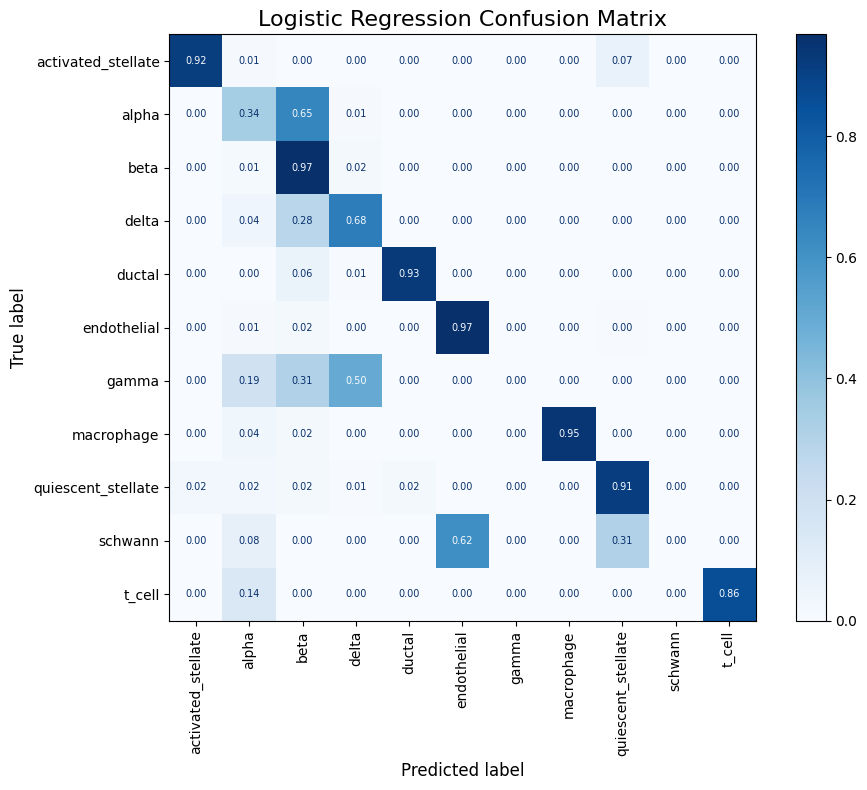


=== k-NN ===
Accuracy: 0.8510835095137421
                    precision    recall  f1-score   support

activated_stellate       0.88      0.95      0.92       284
             alpha       0.92      0.90      0.91      2326
              beta       0.89      0.82      0.85      2525
             delta       0.46      0.87      0.60       601
            ductal       1.00      0.97      0.98      1077
       endothelial       0.99      0.97      0.98       252
             gamma       0.86      0.02      0.05       255
        macrophage       1.00      0.96      0.98        55
quiescent_stellate       0.93      0.75      0.83       173
           schwann       1.00      0.92      0.96        13
            t_cell       0.78      1.00      0.88         7

          accuracy                           0.85      7568
         macro avg       0.88      0.83      0.81      7568
      weighted avg       0.88      0.85      0.85      7568



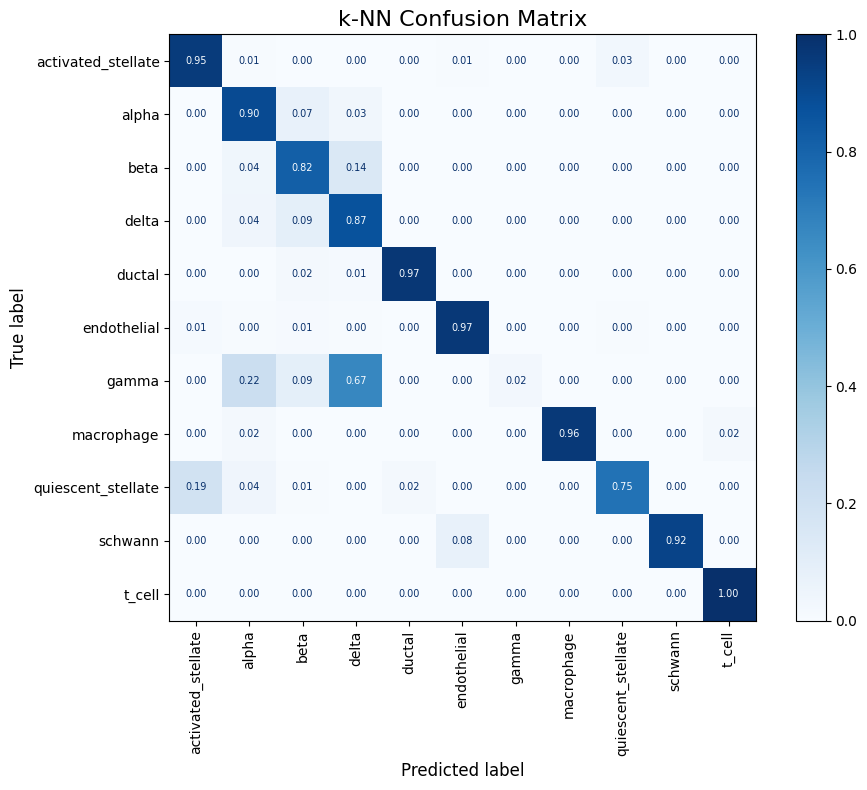

C:\Users\loq\AppData\Local\Temp\ipykernel_23644\481307068.py:72: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  test_data.obs["y_pred_lr"] = y_pred_lr


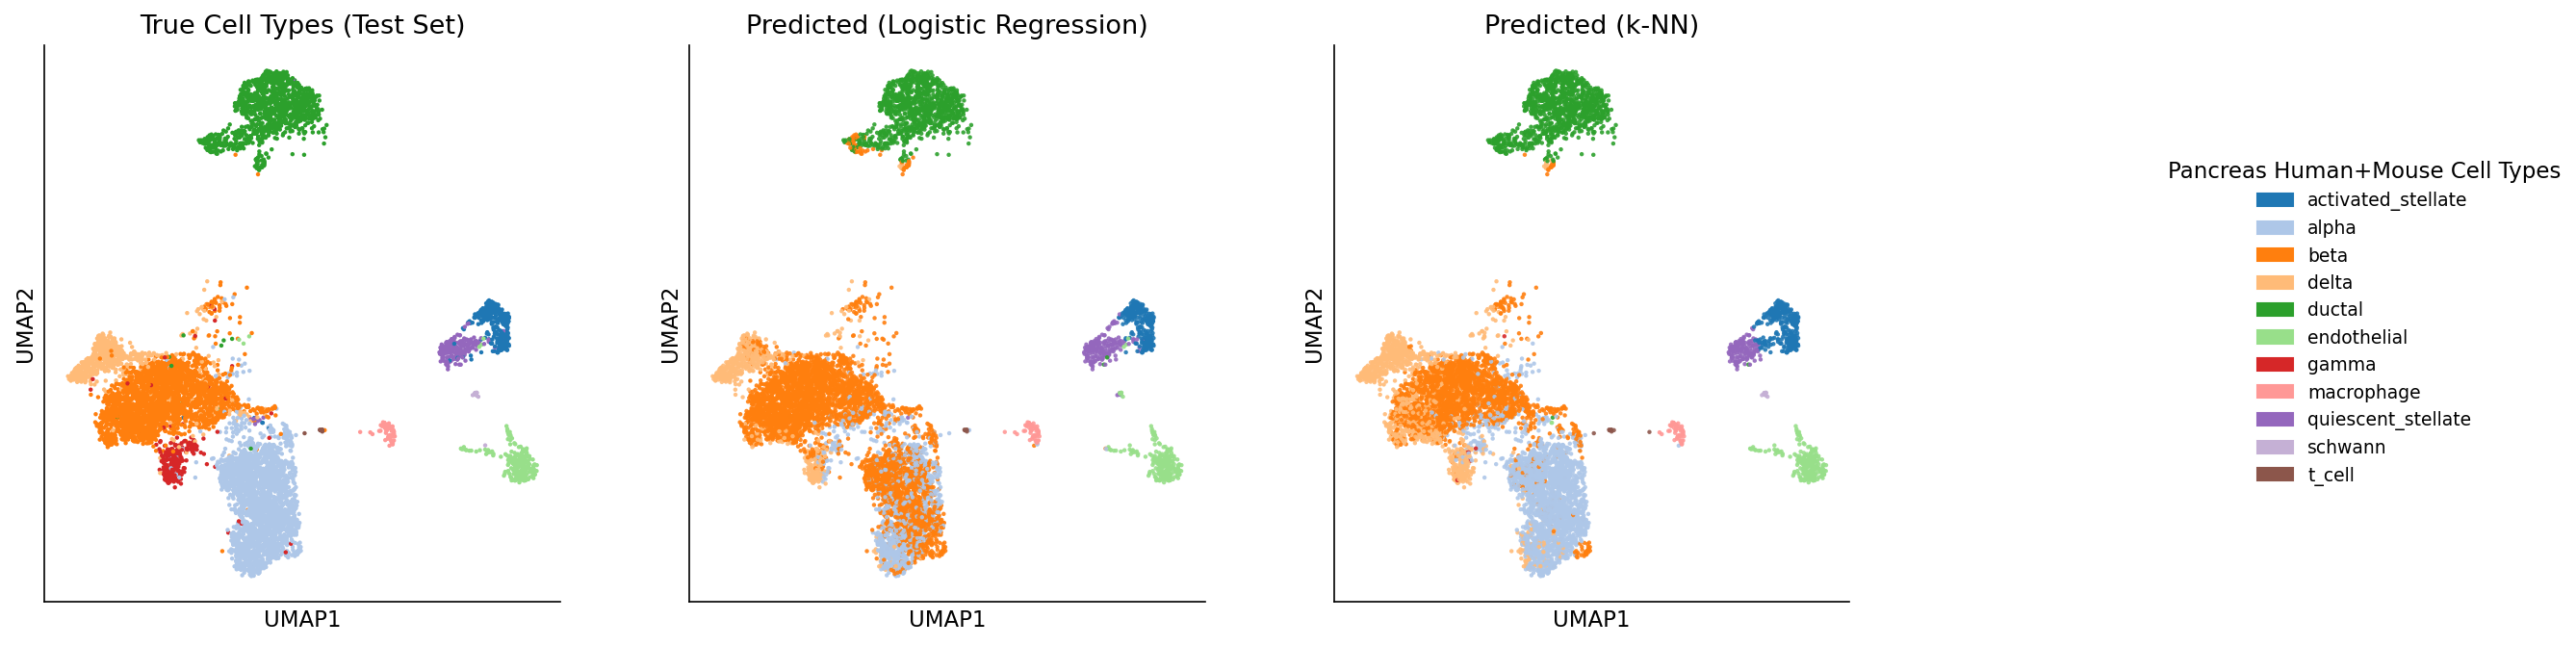

In [17]:

## Visualization

from sklearn.metrics import ConfusionMatrixDisplay


train_data = adata_1[adata_1.obs["species"] == "mouse"]
test_data  = adata_1[adata_1.obs["species"] != "mouse"]

X_train = train_data.obsm["X_emb"]
X_test  = test_data.obsm["X_emb"]

y_train = train_data.obs["cell_type"]
y_test  = test_data.obs["cell_type"]


# logistic regression
clf = LogisticRegression(max_iter=300, solver='lbfgs')

clf.fit(X_train, y_train)
y_pred_lr = clf.predict(X_test)

# KNN
knn = KNeighborsClassifier(
    n_neighbors=15,
    weights="distance",
    metric="cosine"
)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

def plot_cm(y_true, y_pred, title):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels, normalize="true")

    fig, ax = plt.subplots(figsize=(10, 8), dpi=100)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels)

    disp.plot(
        ax=ax,
        cmap="Blues",
        xticks_rotation=90,
        values_format=".2f",
        colorbar=True
    )

    # Make text smaller
    for text in ax.texts:
        text.set_fontsize(7)

    plt.title(title, fontsize=16)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)

    plt.tight_layout()
    plt.show()

print("=== Logistic Regression ===")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
plot_cm(y_test, y_pred_lr, "Logistic Regression Confusion Matrix")


print("\n=== k-NN ===")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
plot_cm(y_test, y_pred_knn, "k-NN Confusion Matrix")

# Attach predictions to test dataset
test_data.obs["y_pred_lr"] = y_pred_lr
test_data.obs["y_pred_knn"] = y_pred_knn

# Fill missing values
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype(str).fillna("Unassigned")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype(str).fillna("Unassigned")

# Convert to categorical
test_data.obs["cell_type"] = test_data.obs["cell_type"].astype("category") # Changed from celltype to cell_type
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].astype("category")
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].astype("category")

# Unified label set
all_labels = sorted(
    set(test_data.obs["cell_type"].cat.categories)
    | set(test_data.obs["y_pred_lr"].cat.categories)
    | set(test_data.obs["y_pred_knn"].cat.categories)
)

# Force same category order
test_data.obs["cell_type"] = test_data.obs["cell_type"].cat.set_categories(all_labels)
test_data.obs["y_pred_lr"] = test_data.obs["y_pred_lr"].cat.set_categories(all_labels)
test_data.obs["y_pred_knn"] = test_data.obs["y_pred_knn"].cat.set_categories(all_labels)

# Color map
palette = sc.pl.palettes.vega_20
color_map = {label: palette[i % len(palette)] for i, label in enumerate(all_labels)}
color_map["Unassigned"] = "lightgray"

# Plot
fig, axes = plt.subplots(1, 3, figsize=(20, 5), dpi=150)

common_kwargs = dict(
    show=False,
    size=18,
    frameon=True,
    palette=color_map
)

# True labels
sc.pl.umap(test_data, color="cell_type", ax=axes[0], **common_kwargs)
axes[0].set_title("True Cell Types (Test Set)", fontsize=13)

# Logistic Regression predictions
sc.pl.umap(test_data, color="y_pred_lr", ax=axes[1], alpha=0.9, **common_kwargs)
axes[1].set_title("Predicted (Logistic Regression)", fontsize=13)

# KNN predictions
sc.pl.umap(test_data, color="y_pred_knn", ax=axes[2], alpha=0.9, **common_kwargs)
axes[2].set_title("Predicted (k-NN)", fontsize=13)

# Remove auto legends
for ax in axes:
    # Remove auto legend
    if ax.legend_:
        ax.legend_.remove()

    # Force white background
    ax.set_facecolor("white")

    # Axis labels
    ax.set_xlabel("UMAP1", fontsize=11)
    ax.set_ylabel("UMAP2", fontsize=11)

    # Make axis lines visible
    ax.spines[['left', 'bottom']].set_visible(True)

    # Remove top/right box lines (clean style)
    ax.spines[['top', 'right']].set_visible(False)

    # Make axes black
    ax.spines[['left', 'bottom']].set_color("black")

    # Ticks
    ax.tick_params(
        axis='both',
        which='major',
        labelsize=9,
        colors='black'
    )
# Single clean legend
from matplotlib.patches import Patch
handles = [Patch(color=color_map[label], label=label) for label in all_labels]
fig.legend(
    handles=handles,
    title="Pancreas Human+Mouse Cell Types",
    loc="center right",
    frameon=False,
    fontsize=9,
    title_fontsize=11,
    ncol=1
)
plt.subplots_adjust(right=0.75, wspace=0.25)
# plt.tight_layout()
plt.show()